<a href="https://colab.research.google.com/github/RohitPoduval1/csci5527-project/blob/main/ResNet50_Truncation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!git clone https://github.com/RohitPoduval1/csci5527-project.git

Cloning into 'csci5527-project'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 92 (delta 3), reused 3 (delta 1), pack-reused 79 (from 1)
Receiving objects: 100% (92/92), 62.85 MiB | 41.04 MiB/s, done.
Resolving deltas: 100% (32/32), done.


In [2]:
# Legacy Keras and VGGFace
!pip install tf-keras
!pip install keras_vggface keras_applications
!pip install kagglehub

import os
# Force tensorflow to use the legacy keras backend
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
import tf_keras as keras
import sys
import kagglehub

# Patch for VGGFace
sys.modules['keras.utils.data_utils'] = tf.keras.utils
sys.modules['keras.utils.layer_utils'] = tf.keras.utils
keras.utils.data_utils = tf.keras.utils
keras.utils.layer_utils = tf.keras.utils

sys.modules['keras'] = keras
sys.modules['keras.engine'] = keras.src.engine
sys.modules['keras.engine.topology'] = keras.utils

from keras_vggface.vggface import VGGFace

from tf_keras.models import load_model
from tf_keras.preprocessing.image import ImageDataGenerator
from tf_keras.models import Model
from tf_keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tf_keras.optimizers.legacy import SGD
from tf_keras.callbacks import ReduceLROnPlateau

import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# Get dataset
dataset_path = kagglehub.dataset_download("msambare/fer2013")
print("Dataset downloaded successfully!")
print("Path to dataset files:", dataset_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.3 MB/s eta 0:00:00
TensorFlow Version: 2.20.0
Using Colab cache for faster access to the 'fer2013' dataset.
Dataset downloaded successfully!
Path to dataset files: /kaggle/input/fer2013


In [3]:
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

# Stanford training augmentations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Test set, scaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Batch size 128, 197x197 images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(197, 197),
    color_mode='rgb',
    shuffle=True,
    class_mode='categorical',
    batch_size=128
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(197, 197),
    color_mode='rgb',
    shuffle=False,
    class_mode='categorical',
    batch_size=128
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [4]:
# Load resnet50 base
vggface_base = VGGFace(model='resnet50', include_top=False,
                       input_shape=(197, 197, 3), pooling=None)  # pooling=None — GAP is added manually below

# Freeze logic
FROZEN_LAYER_NUM = 126  # was 170 in NB1 — now stops at end of res4, before res5
batch_norm_indices = [2, 6, 9, 13, 17, 20, 24, 28, 31, 35, 39, 42, 46,
                      50, 53, 57, 61, 64, 68, 72, 75, 79, 83, 86, 90, 94,
                      97, 101, 105, 108, 112, 116, 119, 123, 127, 130, 134, 138]

for i in range(FROZEN_LAYER_NUM):
    if i not in batch_norm_indices:
        vggface_base.layers[i].trainable = False

# Truncation: sever at end of res4, bypass res5
layers = vggface_base.layers
truncation_layer = None

for i, layer in enumerate(layers):
    if 'conv4_5' in layer.name:
        truncation_layer = layers[i - 1]
        print(f"Truncating at: {truncation_layer.name}")
        break

truncation_output = truncation_layer.output

# Classification head
x = GlobalAveragePooling2D(name='gap_truncated')(truncation_output)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu', name='fc6')(x)   # was 4096
x = Dropout(0.6)(x)
x = Dense(256, activation='relu', name='fc7')(x)    # was 1024
x = Dropout(0.6)(x)
out = Dense(7, activation='softmax', name='classifier')(x)

model = Model(vggface_base.input, out)

# SGD, nesterov momentum
sgd = SGD(learning_rate=0.001, momentum=0.9, decay=0.0001, nesterov=True)

# Learning rate scheduler
rlrop = ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
print("Stanford-Replicated TensorFlow Baseline Constructed.")

94694792/94694792 [==============================] - 1s 0us/step
Truncating at: activation_33
Stanford-Replicated TensorFlow Baseline Constructed.


In [5]:
epochs = 100

print("Starting Baseline Training...")

history = model.fit_generator(
    generator=train_generator,
    validation_data=validation_generator,
    steps_per_epoch=28709 // 128,
    validation_steps=7178 // 128,
    shuffle=True,
    epochs=100,
    callbacks=[rlrop],
    use_multiprocessing=True,
)

# Save tensorflow weights
model.save('tf_stanford_resnet50_truncate.h5')
print("Model saved to tf_stanford_resnet50_truncate.h5")

Starting Baseline Training...


/tmp/ipykernel_5943/3058287569.py:5: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/100
224/224 [==============================] - 546s 2s/step - loss: 1.9158 - accuracy: 0.2091 - val_loss: 1.8387 - val_accuracy: 0.2475 - lr: 0.0010
Epoch 2/100
224/224 [==============================] - 455s 2s/step - loss: 1.8165 - accuracy: 0.2426 - val_loss: 1.8342 - val_accuracy: 0.2254 - lr: 0.0010
Epoch 3/100
224/224 [==============================] - 489s 2s/step - loss: 1.7356 - accuracy: 0.2911 - val_loss: 1.7795 - val_accuracy: 0.2723 - lr: 0.0010
Epoch 4/100
224/224 [==============================] - 486s 2s/step - loss: 1.5573 - accuracy: 0.3801 - val_loss: 1.4671 - val_accuracy: 0.4530 - lr: 0.0010
Epoch 5/100
224/224 [==============================] - 458s 2s/step - loss: 1.4481 - accuracy: 0.4286 - val_loss: 1.3571 - val_accuracy: 0.4763 - lr: 0.0010
Epoch 6/100
224/224 [==============================] - 467s 2s/step - loss: 1.3950 - accuracy: 0.4468 - val_loss: 1.2882 - val_accuracy: 0.5264 - lr: 0.0010
Epoch 7/100
224/224 [==============================] - 452

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved to tf_stanford_resnet50_truncate.h5


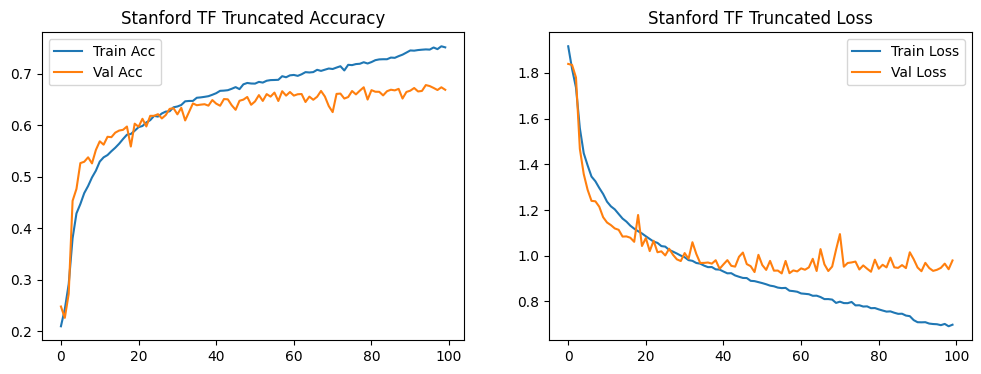

In [6]:
# Plotting the results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Stanford TF Truncated Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Stanford TF Truncated Loss')
plt.legend()
plt.show()

In [7]:
model_path = 'tf_stanford_resnet50_truncate.h5'

if os.path.exists(model_path):
    print(f"Loading saved model from '{model_path}'...")

    # Load saved weights
    loaded_model = load_model(model_path)

    # Evaluate
    loss, accuracy = loaded_model.evaluate(validation_generator, verbose=1)

    print("\nFinal Evaluation Results")
    print(f"Loss:     {loss:.4f}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
else:
    print(f"Error: Could not find '{model_path}'")

Loading saved model from 'tf_stanford_resnet50_truncate.h5'...
57/57 [==============================] - 19s 284ms/step - loss: 0.9779 - accuracy: 0.6694

Final Evaluation Results
Loss:     0.9779
Accuracy: 66.94%
